In [28]:
from google.colab import drive

drive.mount('/content/drive')

# 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Google Drive path (for Colab)
file_path = "/content/drive/MyDrive/Data/tsa-analysis-Japan/data/JTA_TSA_2023.xlsx"
# file_path = "../data/JTA_TSA_2023.xlsx"  # for GitHub execution

xls = pd.ExcelFile(file_path)
xls.sheet_names

['Contents',
 'Summary',
 '概要',
 'Table1',
 'Table2',
 'Table3',
 'Table4',
 'Table5',
 'Table6',
 'Table6b',
 'Table7',
 'Table8',
 'Appendix']

In [36]:
pd.read_excel(file_path, sheet_name=sheet_name, header=None)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,Table 6b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tourism domestic supply and internal tourism c...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,第６b表 国内観光供給及び内部観光消費（日本独自基準）,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,(2023年 CY2023),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,（単位：10億円 Billion Yen）
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tourism industries 観光産業,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,1. Accommodation \nfor visitors,1.a. Accommodation\nservices for visitors\nex...,1.b. \nVacation home\nownership\n(imputed),2. Food- and\nbeverage-serving\nindustry\n,3. Railway\npassenger\ntransport,4. Road\npassenger\ntransport,5. Water\ntransport,6. Air\ntransport,...,Total,Other\nindustries,Tourism domestic supply\nin service\n(at produ...,Imports,Taxes less subsidies on products nationally pr...,Trade and\ntransport\nmargins,Internal\ntourism\nconsumption,Domestic supply\n(at purchasers’\nprices),Tourism ratios\n(%),NaN
6,NaN,NaN,宿泊業,宿泊業\n（1.bを除く）,別荘\n（帰属家賃）,飲食業,鉄道旅客輸送,道路旅客輸送,水運,航空輸送,...,観光産業 計,その他の産業,国内観光供給\n財貨・サービス 計\n（生産者価格）,輸入,国内生産・輸入品に\n課される税\n（控除）補助金,商業・運輸\nマージン,内部観光消費,国内供給\n（購入者価格）,観光比率\n（％）,NaN
7,NaN,Products\n商品,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,(4.3)\n=(6b.11)+(6b.12)\n+(6b.13)+(6b.14),NaN,(6b.16) =,NaN
8,NaN,NaN,(6b.1),(6b.1a),(6b.1b),(6b.2),(6b.3),(6b.4),(6b.5),(6b.6),...,(6b.9),(6b.10),(6b.11) \n= (6b.9) + (6b.10),(6b.12),(6b.13),(6b.14),NaN,(6b.15),(4.3) x 100\n (6b.15),NaN
9,NaN,A. Consumption products (*)\n消費商品,7262,6775,487,3746,2532,489,125,2597,...,19429,8511,27940,1274,229,-26,29417,1205229,2.4,NaN


In [43]:
# =========================
# 1. ファイル読み込み
#    Table6 を読み込み
# =========================
sheet_name = "Table6b"

# 列名をそのまま使わない
df_raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

# =========================
# 2. 列名を取得
#    行7（Excel上）= pandasでは index 6
# =========================
col_names = df_raw.iloc[6].tolist()

# B列〜U列あたりを使う
# pandas上では 0始まりなので:
# 1 = B列
# 2 = C列
# ...
# 20 = U列
df = df_raw.iloc[:, 1:21].copy()

# 列名設定
df.columns = col_names[1:21]

In [58]:
# =========================
# 3. 必要な行だけ抽出
#    Excelの row 47〜51
#    pandas index は 0始まりなので row47 -> index 46
# =========================
gva_rows = df_raw.iloc[46:51, 1:21].copy()
gva_rows.columns = col_names[1:21]

# 行名（B列）
gva_rows = gva_rows.rename(columns={gva_rows.columns[0]: "item"})

# 確認
print(gva_rows[["item"]].head())

                                                 item
46  (I - II). Total gross value added (at producer...
47               Consumption of fixed capital\n固定資本減耗
48                   Compensation of employees\n雇用者報酬
49  Other taxes less subsidies on production and i...
50  Gross operating surplus and gross mixed income...


# 46 Gross Value Added（付加価値合計）
# 47 固定資本減耗（減価償却）
# 48 雇用者報酬
# 49 税−補助金
# 50 営業余剰・混合所得

付加価値合計 = 固定資本減耗 + 雇用者報酬 + 税−補助金 + 営業余剰・混合所得

① 雇用者報酬 👉 従業員の給料

② 固定資本減耗 👉 機械や建物の消耗分（減価償却）

③ 税 ー 補助金 👉 政府へ

④ 営業余剰・混合所得 👉 企業の利益や個人事業主の所得

つまり、生み出された価値は必ずこの4つに分かれる

ーーーーーーーーーーーーーーーーーーーーーーーーーーー

① 観光消費

→ お金の使い道

② 観光比率

→ どの産業に流れたか

③ 観光GVA

→ その結果、誰の所得になったか

In [104]:
# =========================
# 4. 産業別GVA（row 47）を取り出す
#    国内総生産（生産者価格）
# =========================
gva_total = gva_rows.iloc[0].copy()

# item以外を series 化
gva_total = gva_total.drop("item")

# 数値化
gva_total = pd.to_numeric(gva_total, errors="coerce")

print("全産業：", gva_total.index)

# 今回まず見やすくするため、
# 「観光産業」だけに絞る
tourism_industries = [
    "宿泊業",
    "宿泊業\n（1.bを除く）",
    "別荘\n（帰属家賃）",
    "飲食業",
    "鉄道旅客輸送",
    "道路旅客輸送",
    "水運",
    "航空輸送",
    "その他の運輸業\n(**)",
    "スポーツ・娯楽業",
    "観光産業　計"
]

gva_by_industry = gva_total.loc[gva_total.index.intersection(tourism_industries)].copy()

# 分解すると
## gva_total.index
## → 全産業の名前一覧
## intersection(...)
## → 「指定した産業」と一致するものだけ残す
## loc[...]
## → その名前の行だけ取る

# 並べ替え（大きい順）
gva_by_industry = gva_by_industry.sort_values(ascending=False)

gva_by_industry.index = gva_by_industry.index.str.replace("\n", " ", regex=False)

print()
print("観光産業：", gva_by_industry.index)
print()
gva_by_industry

全産業： Index(['宿泊業', '宿泊業\n（1.bを除く）', '別荘\n（帰属家賃）', '飲食業', '鉄道旅客輸送', '道路旅客輸送', '水運',
       '航空輸送', 'その他の運輸業\n(**)', 'スポーツ・娯楽業', '観光産業　計', 'その他の産業',
       '国内観光供給\n財貨・サービス　計\n（生産者価格）', '輸入', '国内生産・輸入品に\n課される税\n（控除）補助金',
       '商業・運輸\nマージン', '内部観光消費', '国内供給\n（購入者価格）', '観光比率\n（％）'],
      dtype='object')

観光産業： Index(['観光産業　計', '宿泊業', '宿泊業 （1.bを除く）', '鉄道旅客輸送', '飲食業', 'スポーツ・娯楽業',
       'その他の運輸業 (**)', '航空輸送', '別荘 （帰属家賃）', '道路旅客輸送', '水運'],
      dtype='object')



,46
観光産業 計,9333.0
宿泊業,3657.0
宿泊業 （1.bを除く）,3218.0
鉄道旅客輸送,1462.0
飲食業,1369.0
スポーツ・娯楽業,914.0
その他の運輸業 (**),866.0
航空輸送,679.0
別荘 （帰属家賃）,440.0
道路旅客輸送,362.0


In [94]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 40.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=f7a86d52ddce180e47ca66009a9e29290e57f2478cfcb6ce4c8e0dbb63fe24e0
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


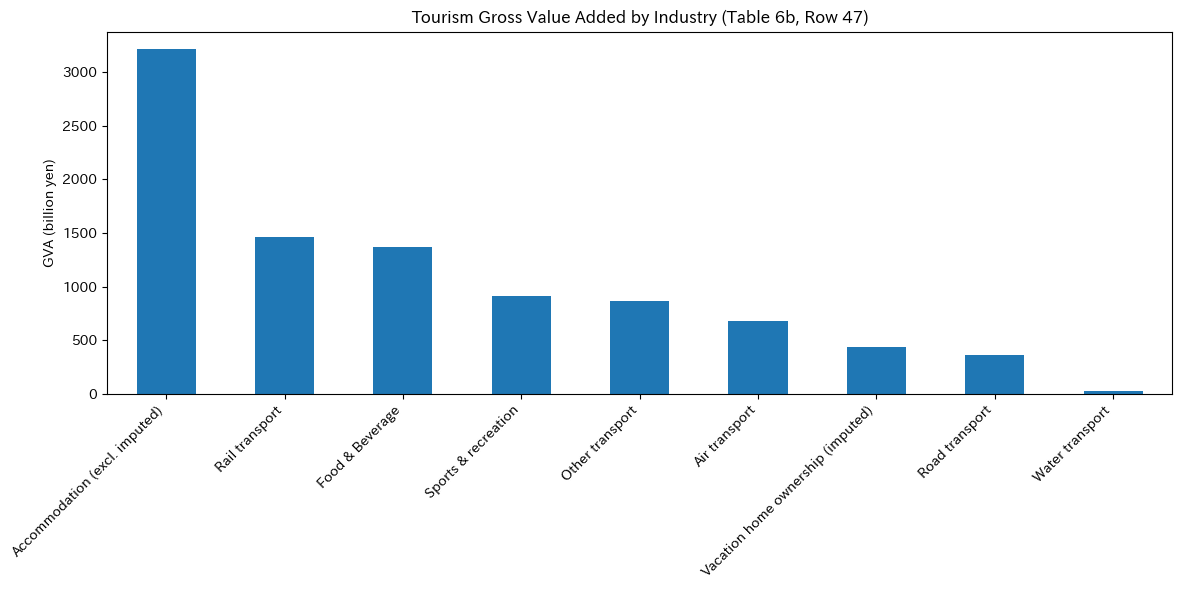

In [117]:
import matplotlib.pyplot as plt
import japanize_matplotlib

gva_no_total = gva_by_industry.drop("観光産業　計")
gva_no_total = gva_no_total.drop("宿泊業")

rename_dict = {
    "宿泊業 （1.bを除く）": "Accommodation (excl. imputed)",
    "別荘 （帰属家賃）": "Vacation home ownership (imputed)",
    "飲食業": "Food & Beverage",
    "鉄道旅客輸送": "Rail transport",
    "道路旅客輸送": "Road transport",
    "水運": "Water transport",
    "航空輸送": "Air transport",
    "その他の運輸業 (**)": "Other transport",
    "スポーツ・娯楽業": "Sports & recreation"
}

gva_no_total_en = gva_no_total.rename(index=rename_dict)

# =========================
# 5. 棒グラフ
# =========================
plt.figure(figsize=(12, 6))
gva_no_total_en.plot(kind="bar")

plt.title("Tourism Gross Value Added by Industry (Table 6b, Row 47)")
plt.ylabel("GVA (billion yen)")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()